# 🗑️ Garbage Image Classification - Data Preparation

## Project Overview
โปรเจคนี้เป็นการสร้าง AI Model สำหรับจำแนกรูปภาพขยะ (Garbage Image Classification)
โดยจะใช้โมเดล Machine Learning 3 โมเดล ได้แก่:
1. **KNN** (K-Nearest Neighbors)
2. **SVM** (Support Vector Machine)
3. **CNN** (Convolutional Neural Network)

### Category Mapping
จำแนกขยะ 10 ประเภทย่อย ให้เป็น 4 กลุ่มหลัก:

| ประเภทย่อย | กลุ่มหลัก |
|---|---|
| Battery | Hazardous |
| Biological | Organic |
| Cardboard, Glass, Metal, Paper, Plastic | Recyclable |
| Clothes, Shoes, Trash | Others |

---
## 1. Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("✅ Import libraries สำเร็จ")

✅ Import libraries สำเร็จ


---
## 2. กำหนด Path และ Category Mapping

In [2]:
# กำหนด path ของชุดข้อมูล
DATA_DIR = 'original'  # โฟลเดอร์ที่เก็บข้อมูลรูปภาพ

# Mapping จากประเภทย่อย -> กลุ่มหลัก
category_map = {
    'battery': 'Hazardous',
    'biological': 'Organic',
    'cardboard': 'Recyclable',
    'glass': 'Recyclable',
    'metal': 'Recyclable',
    'paper': 'Recyclable',
    'plastic': 'Recyclable',
    'clothes': 'Others',
    'shoes': 'Others',
    'trash': 'Others'
}

# กำหนดขนาดรูปภาพที่ต้องการ resize
IMG_SIZE = 128  # 128x128 pixels

# แสดง category mapping
print("Category Mapping:")
for sub, main in category_map.items():
    print(f"   {sub:<12} -> {main}")

print(f"\nData Directory: {DATA_DIR}")
print(f"Image Size: {IMG_SIZE}x{IMG_SIZE}")

Category Mapping:
   battery      -> Hazardous
   biological   -> Organic
   cardboard    -> Recyclable
   glass        -> Recyclable
   metal        -> Recyclable
   paper        -> Recyclable
   plastic      -> Recyclable
   clothes      -> Others
   shoes        -> Others
   trash        -> Others

Data Directory: original
Image Size: 128x128


---
## 3. สำรวจข้อมูล (Data Exploration)
สำรวจจำนวนรูปภาพในแต่ละประเภท และแสดงสถิติของชุดข้อมูล

In [3]:
# นับจำนวนรูปภาพในแต่ละประเภท
sub_category_counts = {}
main_category_counts = {}

for folder_name in os.listdir(DATA_DIR):
    folder_path = os.path.join(DATA_DIR, folder_name)
    if os.path.isdir(folder_path):
        # นับจำนวนไฟล์ภาพในโฟลเดอร์
        valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp')
        num_images = len([f for f in os.listdir(folder_path) 
                         if f.lower().endswith(valid_extensions)])
        sub_category_counts[folder_name] = num_images
        
        # รวมจำนวนตามกลุ่มหลัก
        main_cat = category_map.get(folder_name.lower(), 'Unknown')
        main_category_counts[main_cat] = main_category_counts.get(main_cat, 0) + num_images

# แสดงสถิติ
print("=" * 50)
print("📊 สถิติจำนวนรูปภาพในแต่ละประเภทย่อย")
print("=" * 50)
total = 0
for cat, count in sorted(sub_category_counts.items()):
    main_cat = category_map.get(cat.lower(), 'Unknown')
    print(f"   {cat:<12} ({main_cat:<12}): {count:>5} รูป")
    total += count
print(f"{'':>27} Total: {total:>5} รูป")

print(f"\n{'=' * 50}")
print("📊 สถิติจำนวนรูปภาพตามกลุ่มหลัก")
print("=" * 50)
for cat, count in sorted(main_category_counts.items()):
    print(f"   {cat:<12}: {count:>5} รูป")
print(f"   {'Total':<12}: {total:>5} รูป")

📊 สถิติจำนวนรูปภาพในแต่ละประเภทย่อย
   battery      (Hazardous   ):   756 รูป
   biological   (Organic     ):   699 รูป
   cardboard    (Recyclable  ):  1411 รูป
   clothes      (Others      ):  1892 รูป
   glass        (Recyclable  ):  1736 รูป
   metal        (Recyclable  ):   930 รูป
   paper        (Recyclable  ):  1336 รูป
   plastic      (Recyclable  ):  1597 รูป
   shoes        (Others      ):  1449 รูป
   trash        (Others      ):   453 รูป
                            Total: 12259 รูป

📊 สถิติจำนวนรูปภาพตามกลุ่มหลัก
   Hazardous   :   756 รูป
   Organic     :   699 รูป
   Others      :  3794 รูป
   Recyclable  :  7010 รูป
   Total       : 12259 รูป


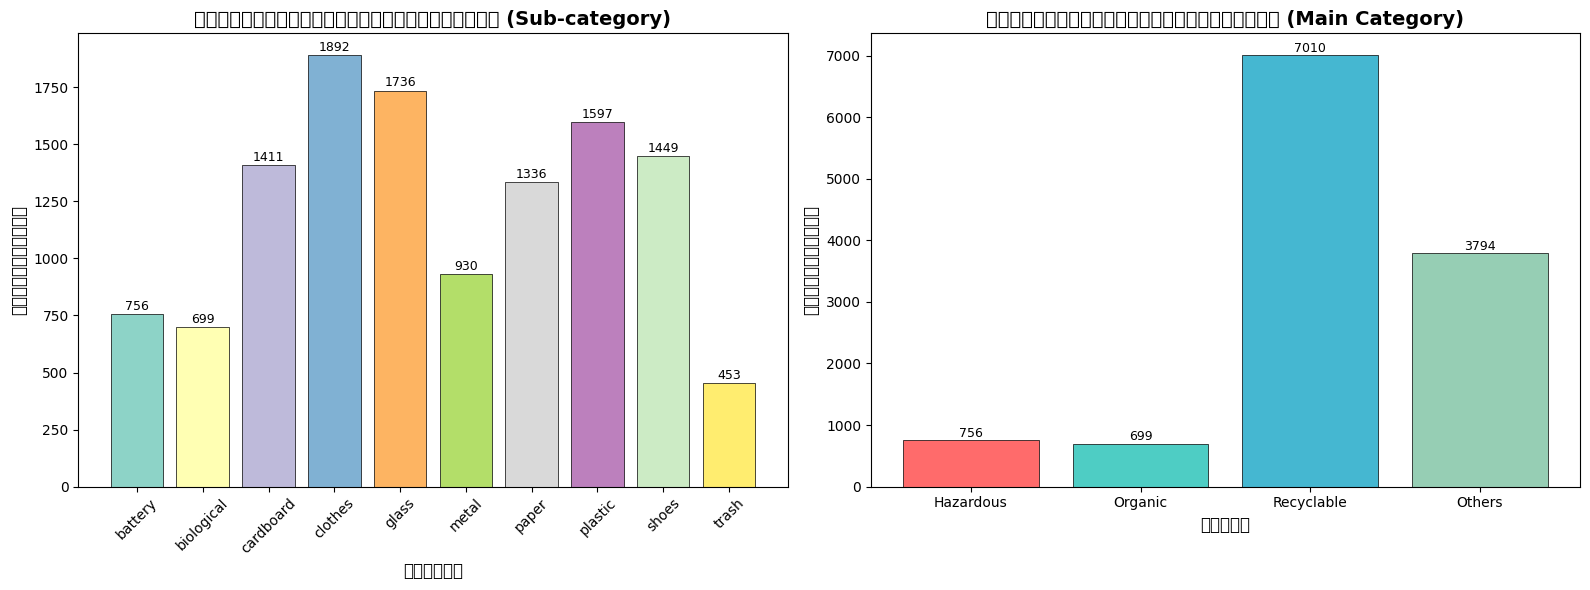

✅ บันทึกกราฟเป็น data_distribution.png


In [4]:
# สร้างกราฟแสดงจำนวนรูปภาพ
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# กราฟ 1: จำนวนรูปภาพแต่ละประเภทย่อย
colors_sub = plt.cm.Set3(np.linspace(0, 1, len(sub_category_counts)))
bars1 = axes[0].bar(sub_category_counts.keys(), sub_category_counts.values(), color=colors_sub, edgecolor='black', linewidth=0.5)
axes[0].set_title('จำนวนรูปภาพแต่ละประเภทย่อย (Sub-category)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('ประเภท', fontsize=12)
axes[0].set_ylabel('จำนวนรูปภาพ', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9)

# กราฟ 2: จำนวนรูปภาพแต่ละกลุ่มหลัก
colors_main = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
bars2 = axes[1].bar(main_category_counts.keys(), main_category_counts.values(), color=colors_main, edgecolor='black', linewidth=0.5)
axes[1].set_title('จำนวนรูปภาพแต่ละกลุ่มหลัก (Main Category)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('กลุ่ม', fontsize=12)
axes[1].set_ylabel('จำนวนรูปภาพ', fontsize=12)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ บันทึกกราฟเป็น data_distribution.png")

---
## 4. แสดงตัวอย่างรูปภาพจากแต่ละประเภท
แสดงตัวอย่างรูปภาพจากแต่ละประเภทย่อยเพื่อให้เข้าใจลักษณะของข้อมูล

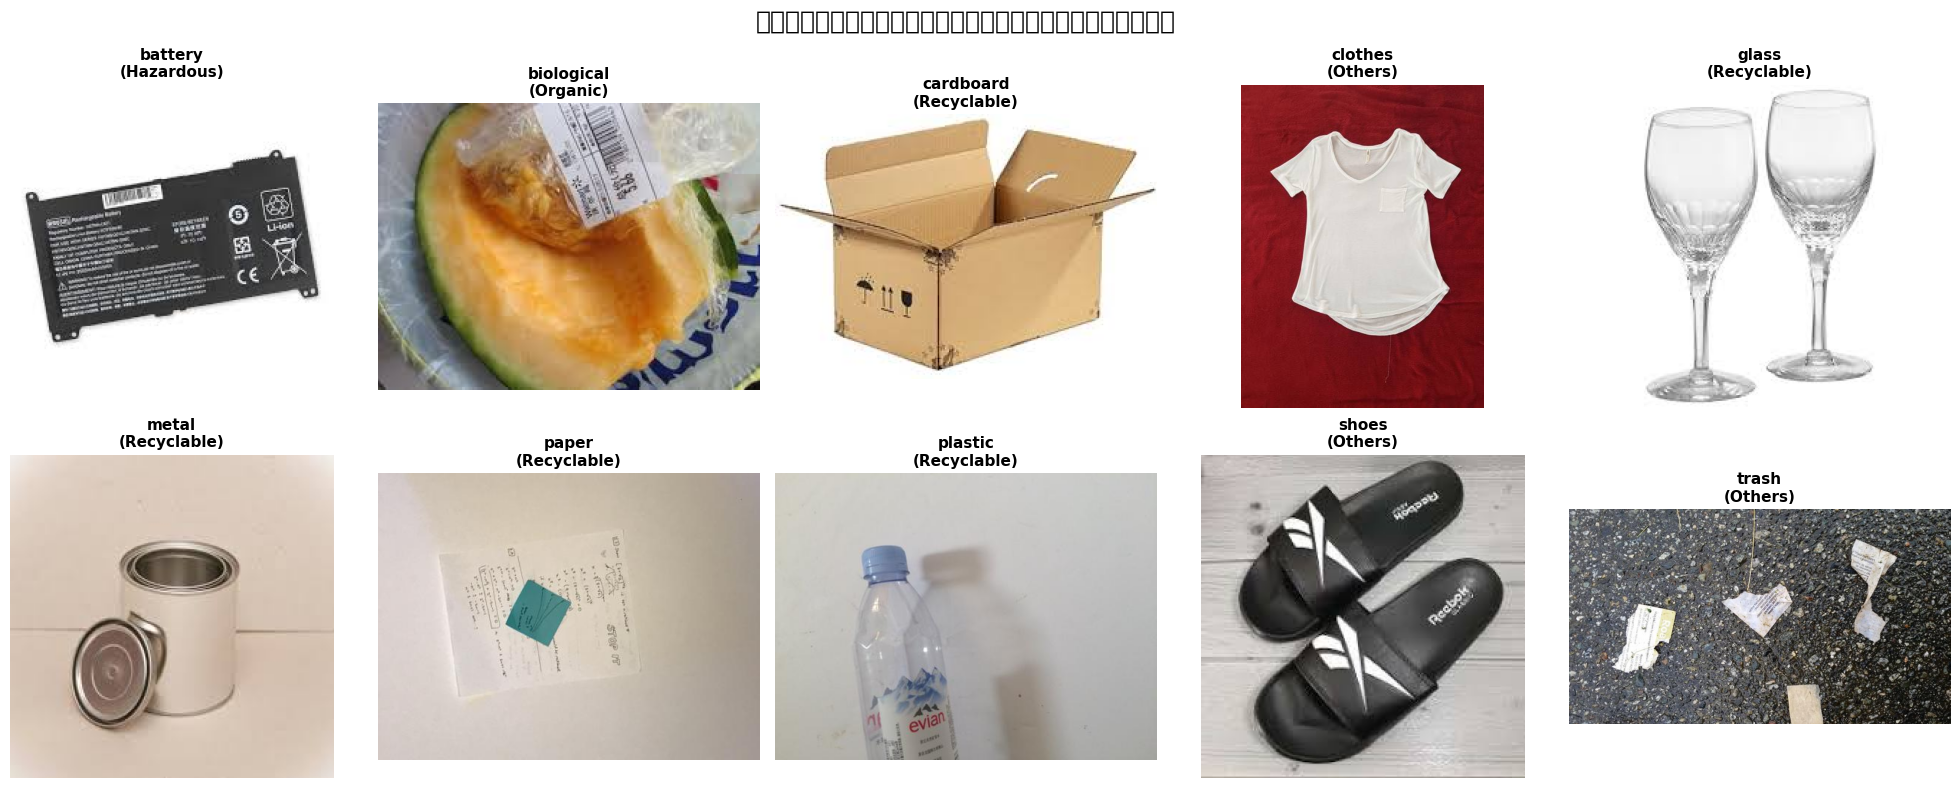

บันทึกตัวอย่างรูปภาพเป็น sample_images.png


In [5]:
# แสดงตัวอย่างรูปภาพจากแต่ละประเภท
categories = sorted(os.listdir(DATA_DIR))
categories = [c for c in categories if os.path.isdir(os.path.join(DATA_DIR, c))]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('ตัวอย่างรูปภาพจากแต่ละประเภท', fontsize=18, fontweight='bold')

for idx, cat in enumerate(categories):
    row = idx // 5
    col = idx % 5
    
    cat_path = os.path.join(DATA_DIR, cat)
    images = [f for f in os.listdir(cat_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'))]
    
    if images:
        img_path = os.path.join(cat_path, images[0])
        img = Image.open(img_path)
        axes[row, col].imshow(img)
    
    main_cat = category_map.get(cat.lower(), 'Unknown')
    axes[row, col].set_title(f"{cat}\n({main_cat})", fontsize=11, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("บันทึกตัวอย่างรูปภาพเป็น sample_images.png")

---
## 5. ตรวจสอบคุณสมบัติของรูปภาพ
ตรวจสอบขนาด, สัดส่วน, และ format ของรูปภาพในชุดข้อมูล

In [6]:
# ตรวจสอบคุณสมบัติของรูปภาพ
img_widths = []
img_heights = []
img_formats = []
img_modes = []

for cat in categories:
    cat_path = os.path.join(DATA_DIR, cat)
    images = [f for f in os.listdir(cat_path) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'))]
    
    for img_name in images:
        try:
            img_path = os.path.join(cat_path, img_name)
            img = Image.open(img_path)
            w, h = img.size
            img_widths.append(w)
            img_heights.append(h)
            img_formats.append(img.format)
            img_modes.append(img.mode)
        except Exception as e:
            print(f"Error reading {img_path}: {e}")

print("=" * 50)
print("📐 คุณสมบัติของรูปภาพ")
print("=" * 50)
print(f"   จำนวนรูปภาพทั้งหมด: {len(img_widths)}")
print(f"   Width  - Min: {min(img_widths)}, Max: {max(img_widths)}, Mean: {np.mean(img_widths):.0f}")
print(f"   Height - Min: {min(img_heights)}, Max: {max(img_heights)}, Mean: {np.mean(img_heights):.0f}")
print(f"   Formats: {Counter(img_formats)}")
print(f"   Modes  : {Counter(img_modes)}")

📐 คุณสมบัติของรูปภาพ
   จำนวนรูปภาพทั้งหมด: 12259
   Width  - Min: 51, Max: 7786, Mean: 440
   Height - Min: 71, Max: 6283, Mean: 431
   Formats: Counter({'JPEG': 12252, 'MPO': 5, 'WEBP': 2})
   Modes  : Counter({'RGB': 12259})


---
## 6. โหลดและ Preprocess รูปภาพ
โหลดรูปภาพทั้งหมด, Resize ให้เป็นขนาดเดียวกัน, แปลงเป็น array และ normalize

In [7]:
def load_and_preprocess_images(data_dir, category_map, img_size=128):
    """
    โหลดรูปภาพทั้งหมดจาก data_dir และทำ preprocessing
    
    Parameters:
    -----------
    data_dir : str - path ของโฟลเดอร์ข้อมูล
    category_map : dict - mapping จากประเภทย่อยไปกลุ่มหลัก
    img_size : int - ขนาดรูปภาพที่ต้องการ resize
    
    Returns:
    --------
    images : numpy array - รูปภาพทั้งหมด shape (n, img_size, img_size, 3)
    sub_labels : list - label ประเภทย่อย
    main_labels : list - label กลุ่มหลัก
    """
    images = []
    sub_labels = []
    main_labels = []
    error_count = 0
    
    categories = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])
    
    for cat in categories:
        cat_path = os.path.join(data_dir, cat)
        img_files = [f for f in os.listdir(cat_path) 
                     if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.webp'))]
        
        print(f"Loading {cat:<12} ... ", end='')
        count = 0
        
        for img_name in img_files:
            try:
                img_path = os.path.join(cat_path, img_name)
                # อ่านรูปภาพด้วย OpenCV
                img = cv2.imread(img_path)
                if img is None:
                    error_count += 1
                    continue
                
                # แปลง BGR -> RGB
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                # Resize
                img = cv2.resize(img, (img_size, img_size))
                
                images.append(img)
                sub_labels.append(cat)
                main_labels.append(category_map.get(cat.lower(), 'Unknown'))
                count += 1
                
            except Exception as e:
                error_count += 1
        
        print(f"{count} รูป")
    
    images = np.array(images)
    
    print(f"\n✅ โหลดรูปภาพเสร็จสิ้น")
    print(f"   จำนวนรูปภาพที่โหลดได้: {len(images)}")
    print(f"   จำนวนรูปภาพที่ error: {error_count}")
    print(f"   Shape: {images.shape}")
    
    return images, sub_labels, main_labels

# โหลดรูปภาพ
print("กำลังโหลดและ preprocess รูปภาพ...\n")
images, sub_labels, main_labels = load_and_preprocess_images(DATA_DIR, category_map, IMG_SIZE)

กำลังโหลดและ preprocess รูปภาพ...

Loading battery      ... 756 รูป
Loading biological   ... 699 รูป
Loading cardboard    ... 1411 รูป
Loading clothes      ... 1892 รูป
Loading glass        ... 1736 รูป
Loading metal        ... 930 รูป
Loading paper        ... 1336 รูป
Loading plastic      ... 1597 รูป
Loading shoes        ... 1449 รูป
Loading trash        ... 453 รูป

✅ โหลดรูปภาพเสร็จสิ้น
   จำนวนรูปภาพที่โหลดได้: 12259
   จำนวนรูปภาพที่ error: 0
   Shape: (12259, 128, 128, 3)


---
## 7. Normalize ข้อมูล
ทำ Normalization โดยแปลงค่า pixel จาก [0, 255] เป็น [0, 1]

In [8]:
# Normalize pixel values
images_normalized = images.astype('float32') / 255.0

print(f"📊 ก่อน Normalize:")
print(f"   Min pixel: {images.min()}, Max pixel: {images.max()}, dtype: {images.dtype}")
print(f"\n📊 หลัง Normalize:")
print(f"   Min pixel: {images_normalized.min():.4f}, Max pixel: {images_normalized.max():.4f}, dtype: {images_normalized.dtype}")
print(f"   Shape: {images_normalized.shape}")

📊 ก่อน Normalize:
   Min pixel: 0, Max pixel: 255, dtype: uint8

📊 หลัง Normalize:
   Min pixel: 0.0000, Max pixel: 1.0000, dtype: float32
   Shape: (12259, 128, 128, 3)


---
## 8. Encode Labels
แปลง label จาก text เป็นตัวเลขด้วย LabelEncoder

In [9]:
# Encode labels สำหรับกลุ่มหลัก (Main Category)
label_encoder = LabelEncoder()
main_labels_encoded = label_encoder.fit_transform(main_labels)

print("📋 Label Encoding (Main Category):")
for i, cls in enumerate(label_encoder.classes_):
    count = np.sum(main_labels_encoded == i)
    print(f"   {cls:<12} -> {i}  ({count} รูป)")

print(f"\n   จำนวน classes: {len(label_encoder.classes_)}")
print(f"   Encoded labels shape: {main_labels_encoded.shape}")

📋 Label Encoding (Main Category):
   Hazardous    -> 0  (756 รูป)
   Organic      -> 1  (699 รูป)
   Others       -> 2  (3794 รูป)
   Recyclable   -> 3  (7010 รูป)

   จำนวน classes: 4
   Encoded labels shape: (12259,)


---
##  Train/Test Split (80/20)
แบ่งข้อมูลเป็น training set (80%) และ test set (20%) โดยใช้ `stratify` เพื่อรักษาสัดส่วน class


In [10]:
TEST_SIZE = 0.2        # สัดส่วน test set (20%)
RANDOM_STATE = 42      # seed สำหรับ reproducibility

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    images_normalized, main_labels_encoded,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=main_labels_encoded  # รักษาสัดส่วนของแต่ละ class
)

print("=" * 50)
print("✂️ ผลการแบ่ง Train/Test Split")
print("=" * 50)
print(f"   X_train shape : {X_train.shape}")
print(f"   X_test shape  : {X_test.shape}")
print(f"   y_train shape : {y_train.shape}")
print(f"   y_test shape  : {y_test.shape}")

# แสดงการกระจายใน train/test
print(f"\n📊 การกระจายใน Training Set:")
train_counter = Counter(y_train)
for label_id in sorted(train_counter.keys()):
    label_name = label_encoder.inverse_transform([label_id])[0]
    count = train_counter[label_id]
    pct = count / len(y_train) * 100
    print(f"   {label_name:<12}: {count:>5} ({pct:.1f}%)")
print(f"   {'Total':<12}: {len(y_train):>5}")

print(f"\n📊 การกระจายใน Test Set:")
test_counter = Counter(y_test)
for label_id in sorted(test_counter.keys()):
    label_name = label_encoder.inverse_transform([label_id])[0]
    count = test_counter[label_id]
    pct = count / len(y_test) * 100
    print(f"   {label_name:<12}: {count:>5} ({pct:.1f}%)")
print(f"   {'Total':<12}: {len(y_test):>5}")


✂️ ผลการแบ่ง Train/Test Split
   X_train shape : (9807, 128, 128, 3)
   X_test shape  : (2452, 128, 128, 3)
   y_train shape : (9807,)
   y_test shape  : (2452,)

📊 การกระจายใน Training Set:
   Hazardous   :   605 (6.2%)
   Organic     :   559 (5.7%)
   Others      :  3035 (30.9%)
   Recyclable  :  5608 (57.2%)
   Total       :  9807

📊 การกระจายใน Test Set:
   Hazardous   :   151 (6.2%)
   Organic     :   140 (5.7%)
   Others      :   759 (31.0%)
   Recyclable  :  1402 (57.2%)
   Total       :  2452


## KNN Modle

In [12]:
from sklearn.decomposition import PCA

X_train_flat = X_train.reshape(X_train.shape[0], -1)  
X_test_flat = X_test.reshape(X_test.shape[0], -1)     

pca = PCA(n_components=9807) 
X_train_pca = pca.fit_transform(X_train_flat)  
X_test_pca = pca.transform(X_test_flat)       

print(f"Flatten shape: {X_train_flat.shape}")
print(f"PCA shape: {X_train_pca.shape}")
print(f"Explained variance: {sum(pca.explained_variance_ratio_):.2%}")


Flatten shape: (9807, 49152)
PCA shape: (9807, 9807)
Explained variance: 100.00%


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)

y_pred_knn = knn.predict(X_test_pca)
print(f"KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(classification_report(y_test, y_pred_knn,
      target_names=['Hazardous','Organic','Others','Recyclable']))


KNN Accuracy: 0.7035
              precision    recall  f1-score   support

   Hazardous       0.87      0.32      0.47       151
     Organic       0.44      0.03      0.05       140
      Others       0.67      0.59      0.63       759
  Recyclable       0.71      0.87      0.79      1402

    accuracy                           0.70      2452
   macro avg       0.67      0.45      0.48      2452
weighted avg       0.69      0.70      0.68      2452



##  กราฟ ACC ของ Train,Test

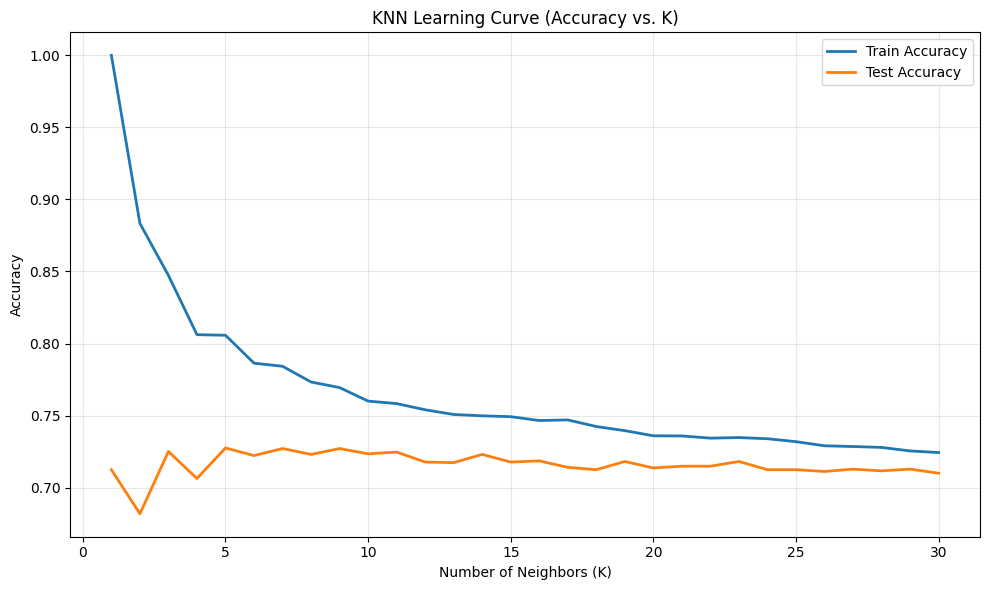

✅ Best K = 5, Test Accuracy = 0.7276


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_range = range(1, 31)
train_accs = []
test_accs = []

for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_pca, y_train)
    train_accs.append(accuracy_score(y_train, knn_temp.predict(X_train_pca)))
    test_accs.append(accuracy_score(y_test, knn_temp.predict(X_test_pca)))

plt.figure(figsize=(10, 6))
plt.plot(k_range, train_accs, label='Train Accuracy', linewidth=2)
plt.plot(k_range, test_accs, label='Test Accuracy', linewidth=2)
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Learning Curve (Accuracy vs. K)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('knn_learning_curve.png', dpi=150)
plt.show()

best_k = list(k_range)[test_accs.index(max(test_accs))]
print(f"✅ Best K = {best_k}, Test Accuracy = {max(test_accs):.4f}")


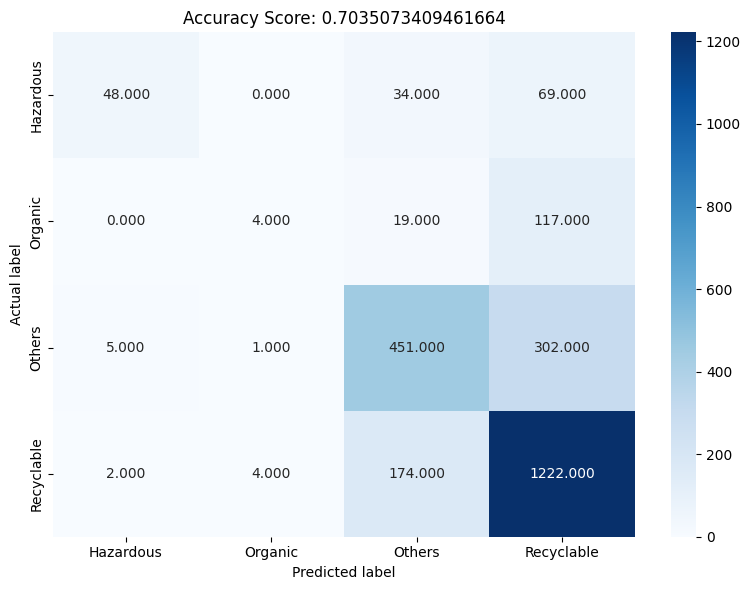

In [15]:
from sklearn.metrics import confusion_matrix, accuracy_score

# สร้าง Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
acc = accuracy_score(y_test, y_pred_knn)

labels = ['Hazardous', 'Organic', 'Others', 'Recyclable']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title(f'Accuracy Score: {acc}')
plt.tight_layout()
plt.savefig('knn_confusion_matrix.png', dpi=150)
plt.show()


## 2.SVM

# 1. Import and Train SVM Model

In [19]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

# SVM with RBF kernel
print("\n  Training SVM (kernel='rbf', C=10, gamma='scale')...")
start_time = time.time()

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    decision_function_shape='ovr',
    random_state=RANDOM_STATE
)
svm_model.fit(X_train_pca, y_train)

train_time = time.time() - start_time
print(f"  ✅ SVM Training completed in {train_time:.2f} seconds")


  Training SVM (kernel='rbf', C=10, gamma='scale')...
  ✅ SVM Training completed in 10.08 seconds


# 2.Evaluate SVM Model

In [20]:
# Predict
y_pred_train = svm_model.predict(X_train_pca)
y_pred_test = svm_model.predict(X_test_pca)

# Accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\n  Training Accuracy : {train_acc:.4f}")
print(f"  Test Accuracy     : {test_acc:.4f}")

# Classification Report
print(f"\n  📋 Classification Report (Test Set):")
print(classification_report(
    y_test, y_pred_test,
    target_names=LABELS,
    digits=4
))


  Training Accuracy : 0.9618
  Test Accuracy     : 0.7696

  📋 Classification Report (Test Set):
              precision    recall  f1-score   support

   Hazardous     0.7273    0.5298    0.6130       151
     Organic     0.5281    0.3357    0.4105       140
      Others     0.7539    0.6943    0.7229       759
  Recyclable     0.7934    0.8795    0.8342      1402

    accuracy                         0.7696      2452
   macro avg     0.7007    0.6098    0.6452      2452
weighted avg     0.7620    0.7696    0.7620      2452



# 3. Confusion Matrix

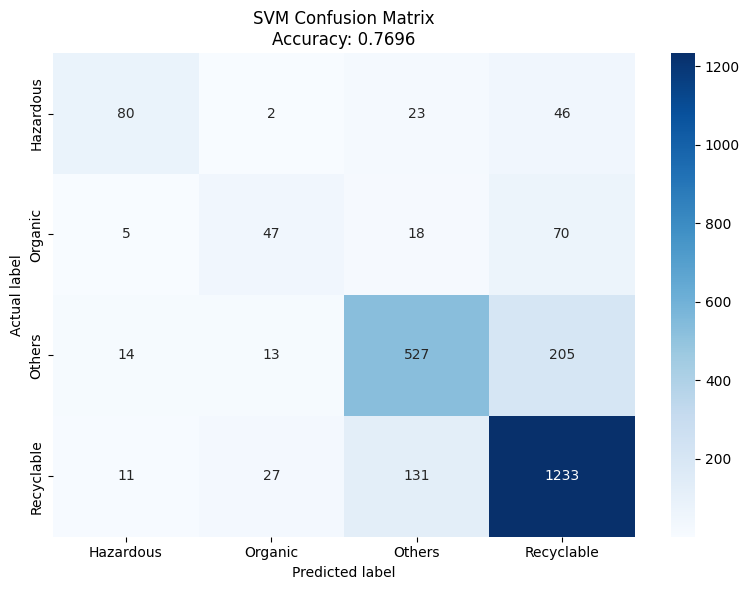

  ✅ Saved: svm_confusion_matrix.png


In [21]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title(f'SVM Confusion Matrix\nAccuracy: {test_acc:.4f}')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150)
plt.show()
print("  ✅ Saved: svm_confusion_matrix.png")

# 4. Normalized Confusion Matrix

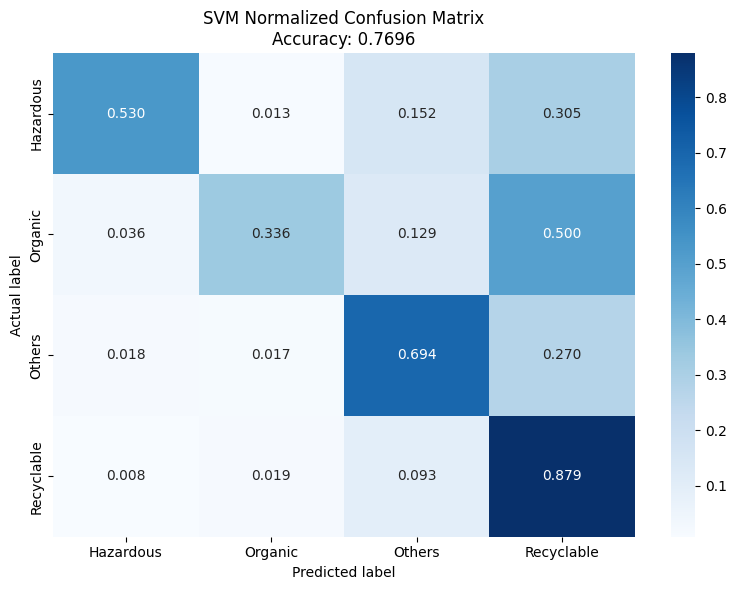

  ✅ Saved: svm_confusion_matrix_normalized.png


In [22]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel('Predicted label')
plt.ylabel('Actual label')
plt.title(f'SVM Normalized Confusion Matrix\nAccuracy: {test_acc:.4f}')
plt.tight_layout()
plt.savefig('svm_confusion_matrix_normalized.png', dpi=150)
plt.show()
print("  ✅ Saved: svm_confusion_matrix_normalized.png")

